# Single-Shot Denoiser — Training

Trains a per-position MLP that uses expected physicochemical properties
(`probs @ property_table`) alongside the raw probability vector to predict
the true amino acid at each position.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import h5py

from models.single_shot import SingleShotDenoiser, make_loaders, run_epoch
from models.properties import AA_ORDER

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

H5_PATH   = Path.cwd().parent / 'data' / 'synthetic' / 'perturbed_n1000_seed42.h5'
MODEL_DIR = Path.cwd().parent / 'models' / 'checkpoints'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DATASET = 'perturb_gamma3'  # which perturbation level to train on
BATCH_SIZE    = 32
HIDDEN_DIM    = 128
N_LAYERS      = 2
DROPOUT       = 0.1
LR            = 1e-3
EPOCHS        = 30
SEED          = 42

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Training on: {TRAIN_DATASET}')

with h5py.File(H5_PATH, 'r') as f:
    classes   = list(f.attrs['classes'])
    all_keys  = list(next(iter(f.values())).keys())

aa_to_idx = {a: i for i, a in enumerate(classes)}
print(f'AA order matches: {classes == AA_ORDER}')
print(f'Available datasets: {[k for k in all_keys if k != "sequence"]}')

Device: cpu
Training on: perturb_gamma3
AA order matches: True
Available datasets: ['ground_truth', 'lowconf_10pct', 'lowconf_1pct', 'lowconf_20pct', 'lowconf_5pct', 'perturb_gamma1', 'perturb_gamma10', 'perturb_gamma3', 'perturb_gamma50', 'scramble_10pct', 'scramble_1pct', 'scramble_20pct', 'scramble_5pct']


In [2]:
train_loader, val_loader, train_pids, val_pids = make_loaders(
    H5_PATH, TRAIN_DATASET, aa_to_idx,
    batch_size=BATCH_SIZE, val_frac=0.2, seed=SEED,
)
print(f'Train: {len(train_pids):,} proteins  |  Val: {len(val_pids):,} proteins')
print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train: 800 proteins  |  Val: 200 proteins
Train batches: 25  |  Val batches: 7


In [3]:
torch.manual_seed(SEED)
model = SingleShotDenoiser(hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS, dropout=DROPOUT).to(DEVICE)

# Fit z-score stats on training data before any gradient steps
model.fit_stats(train_loader, device=DEVICE)
print(f'Property means: {model.prop_mean.numpy().round(3)}')
print(f'Property stds:  {model.prop_std.numpy().round(3)}')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Property means: [-9.3000e-02  3.2252e+01 -1.0000e-03  1.2700e-01  2.5000e-02  2.4500e-01
  2.4000e-01]
Property stds:  [ 1.46  59.975  0.231  0.331  0.152  0.458  0.46 ]
Trainable parameters: 22,676


In [4]:
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer, DEVICE, train=True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   optimizer, DEVICE, train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_DIR / f'single_shot_{TRAIN_DATASET}.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | '
              f'train loss {train_loss:.4f} acc {train_acc:.3%} | '
              f'val loss {val_loss:.4f} acc {val_acc:.3%}')

print(f'Best val loss: {best_val_loss:.4f}')

Epoch   1 | train loss 2.5551 acc 26.966% | val loss 1.9160 acc 43.222%
Epoch   5 | train loss 0.0648 acc 99.144% | val loss 0.0342 acc 99.421%
Epoch  10 | train loss 0.0249 acc 99.413% | val loss 0.0191 acc 99.512%
Epoch  15 | train loss 0.0206 acc 99.453% | val loss 0.0173 acc 99.534%
Epoch  20 | train loss 0.0192 acc 99.468% | val loss 0.0166 acc 99.541%
Epoch  25 | train loss 0.0186 acc 99.477% | val loss 0.0165 acc 99.539%
Epoch  30 | train loss 0.0188 acc 99.465% | val loss 0.0164 acc 99.540%
Best val loss: 0.0164


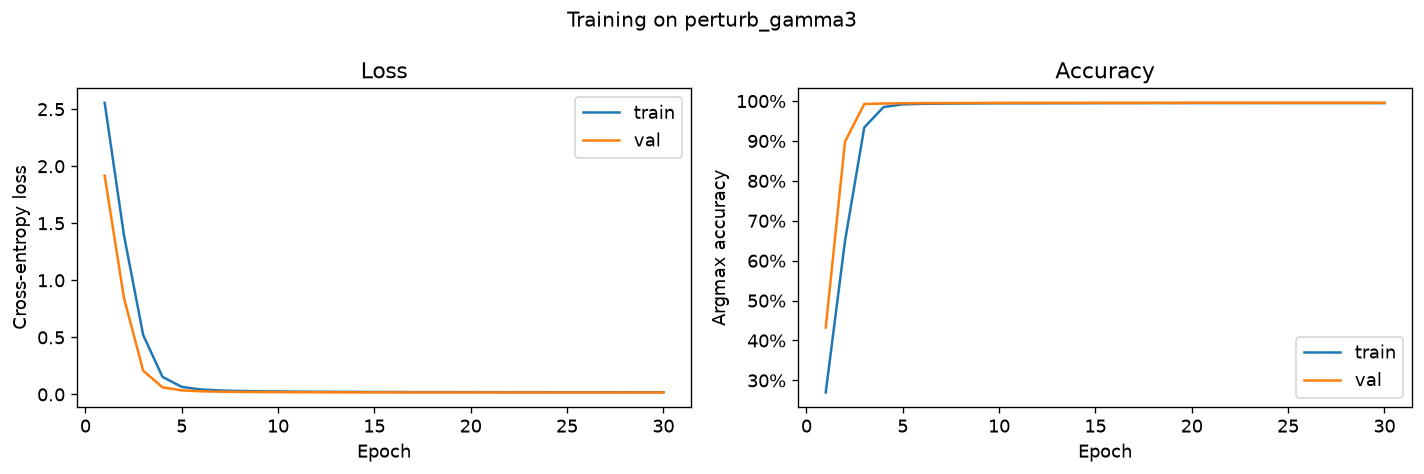

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], label='train')
axes[0].plot(epochs, history['val_loss'],   label='val')
axes[0].set(xlabel='Epoch', ylabel='Cross-entropy loss', title='Loss')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='train')
axes[1].plot(epochs, history['val_acc'],   label='val')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set(xlabel='Epoch', ylabel='Argmax accuracy', title='Accuracy')
axes[1].legend()

fig.suptitle(f'Training on {TRAIN_DATASET}', fontsize=12)
fig.tight_layout()
plt.show()

## Evaluation across all perturbation levels

Load the best checkpoint and evaluate on every dataset in the HDF5 file.

In [6]:
from models.single_shot import ProteinDataset, collate_fn
from torch.utils.data import DataLoader
import torch.nn.functional as F

# Load best checkpoint
model.load_state_dict(torch.load(MODEL_DIR / f'single_shot_{TRAIN_DATASET}.pt', map_location=DEVICE))
model.eval()

EVAL_KEYS = [
    'ground_truth',
    'perturb_gamma50', 'perturb_gamma10', 'perturb_gamma3', 'perturb_gamma1',
    'scramble_1pct', 'scramble_5pct', 'scramble_10pct', 'scramble_20pct',
]
EVAL_LABELS = [
    'ground truth',
    'γ=50', 'γ=10', 'γ=3', 'γ=1',
    's=1%', 's=5%', 's=10%', 's=20%',
]

results = {}
for key in EVAL_KEYS:
    ds     = ProteinDataset(H5_PATH, key, val_pids, aa_to_idx)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    _, acc = run_epoch(model, loader, None, DEVICE, train=False)
    results[key] = acc
    print(f'{key:25s}  acc = {acc:.3%}')

ground_truth               acc = 100.000%
perturb_gamma50            acc = 100.000%
perturb_gamma10            acc = 99.999%
perturb_gamma3             acc = 99.540%
perturb_gamma1             acc = 96.453%
scramble_1pct              acc = 99.043%
scramble_5pct              acc = 95.259%
scramble_10pct             acc = 90.499%
scramble_20pct             acc = 80.995%


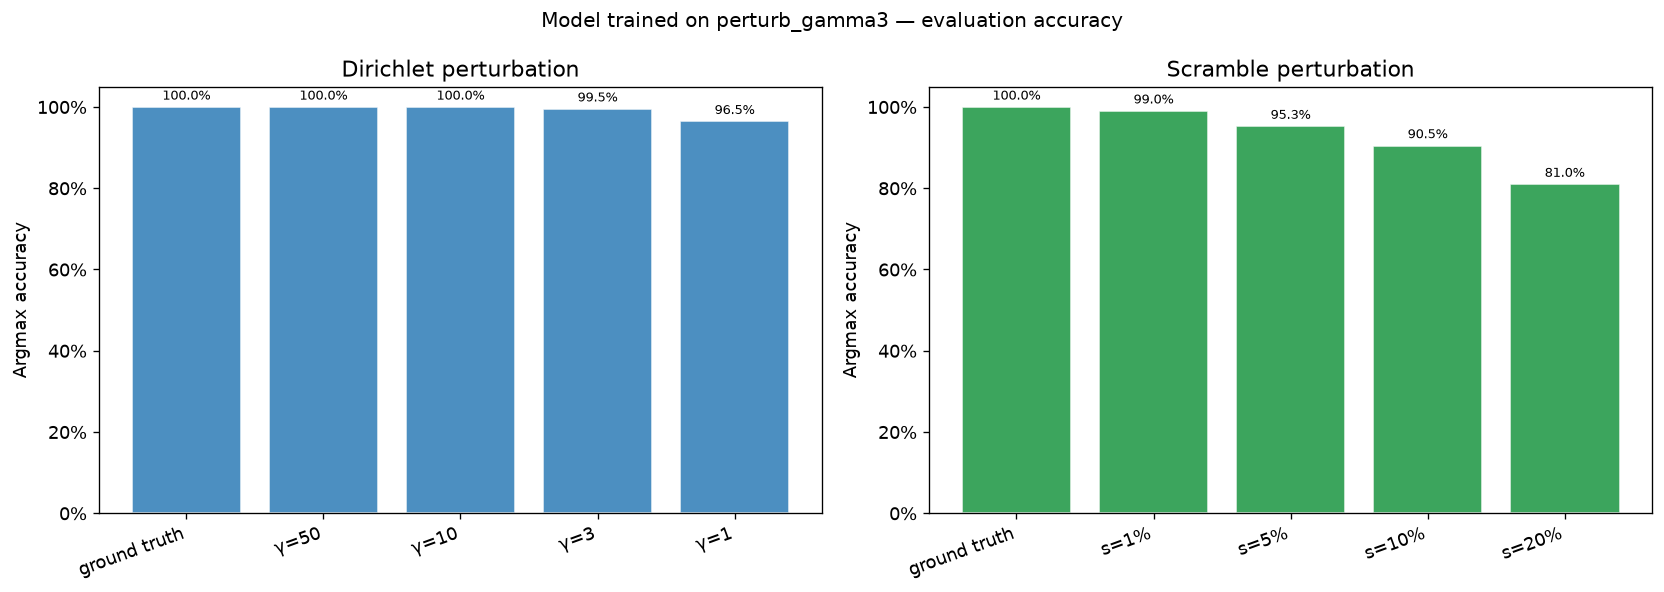

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dirichlet_keys   = ['ground_truth', 'perturb_gamma50', 'perturb_gamma10', 'perturb_gamma3', 'perturb_gamma1']
dirichlet_labels = ['ground truth', 'γ=50', 'γ=10', 'γ=3', 'γ=1']
scramble_keys    = ['ground_truth', 'scramble_1pct', 'scramble_5pct', 'scramble_10pct', 'scramble_20pct']
scramble_labels  = ['ground truth', 's=1%', 's=5%', 's=10%', 's=20%']

for ax, keys, labels, color, title in [
    (axes[0], dirichlet_keys,  dirichlet_labels,  '#2c7bb6', 'Dirichlet perturbation'),
    (axes[1], scramble_keys,   scramble_labels,   '#1a9641', 'Scramble perturbation'),
]:
    vals = [results[k] for k in keys]
    bars = ax.bar(np.arange(len(keys)), vals, color=color, edgecolor='white', alpha=0.85)
    ax.set_xticks(np.arange(len(keys)))
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set(ylabel='Argmax accuracy', title=title, ylim=(0, 1.05))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.1%}',
                ha='center', va='bottom', fontsize=8)

fig.suptitle(f'Model trained on {TRAIN_DATASET} — evaluation accuracy', fontsize=12)
fig.tight_layout()
plt.show()